# Assignment 2 — Question 4: PCA + K-Means

Dataset: `mobile_price.csv` (2000 samples, 20 features, 4 balanced classes `price_range ∈ {0,1,2,3}`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

os.makedirs('chart', exist_ok=True)
SEED = 42

## Q4(a) — Standardise features, project onto first two principal components, scatter coloured by class

In [2]:
df = pd.read_csv('data/mobile_price.csv')
X = df.drop(columns=['price_range']).values.astype(float)
y = df['price_range'].values

# z-score standardisation
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 2-D PCA projection
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_std)

print(f'X shape: {X.shape},  X_std shape: {X_std.shape},  X_pca shape: {X_pca.shape}')
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Cumulative explained variance: {pca.explained_variance_ratio_.sum():.4f}')

X shape: (2000, 20),  X_std shape: (2000, 20),  X_pca shape: (2000, 2)
Explained variance ratio: [0.08386288 0.08112475]
Cumulative explained variance: 0.1650


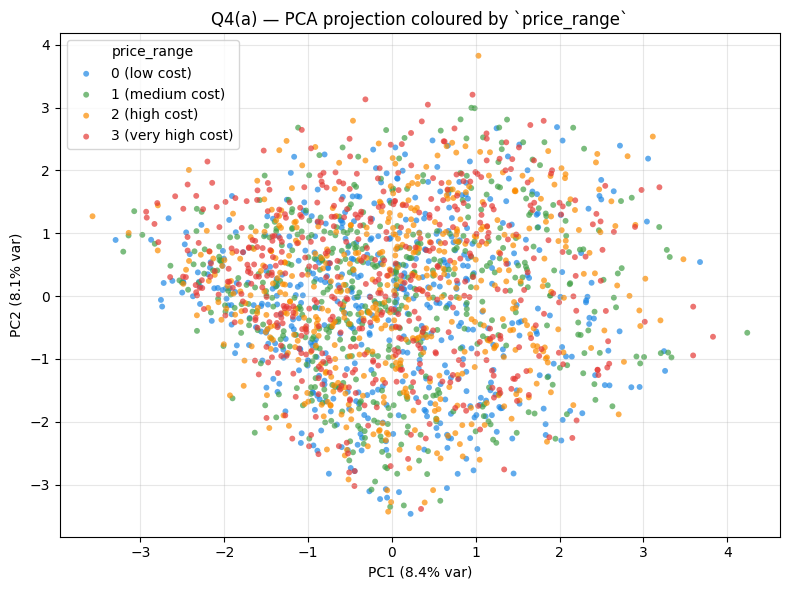

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1E88E5', '#43A047', '#FB8C00', '#E53935']
labels = ['0 (low cost)', '1 (medium cost)', '2 (high cost)', '3 (very high cost)']

for cls in range(4):
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=18, alpha=0.7,
               color=colors[cls], label=labels[cls], edgecolor='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Q4(a) — PCA projection coloured by `price_range`')
ax.legend(title='price_range', loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('chart/Q4a_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Q4(b) — K-Means on **all** standardised features (k = 4)

Cluster in the original 20-D standardised space, then project onto the 2-D PCA axes for visualisation.

In [4]:
km_all = KMeans(n_clusters=4, random_state=SEED, n_init=10)
labels_all = km_all.fit_predict(X_std)

ari_all = adjusted_rand_score(y, labels_all)
print(f'Q4(b) — KMeans on all features (20-D)')
print(f'  Adjusted Rand Index: {ari_all:.4f}')

Q4(b) — KMeans on all features (20-D)
  Adjusted Rand Index: 0.0060


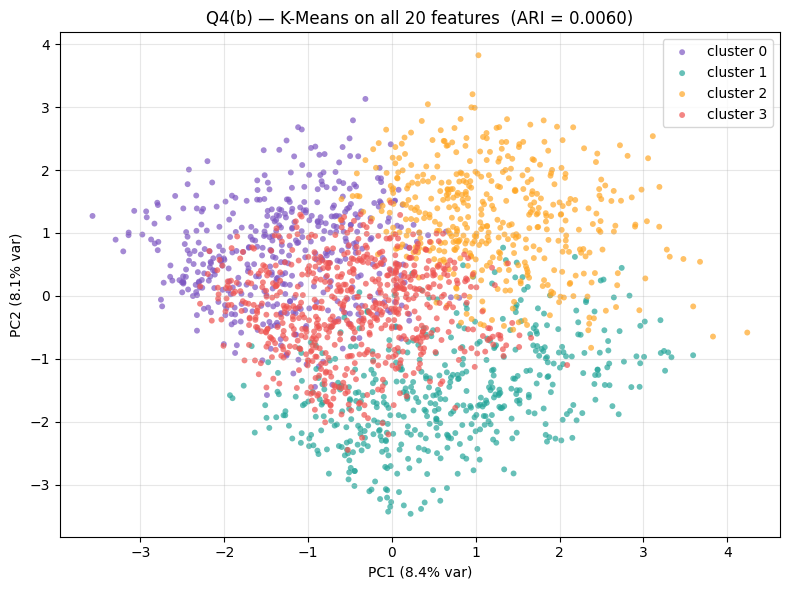

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
cluster_colors = ['#7E57C2', '#26A69A', '#FFA726', '#EF5350']

for k in range(4):
    mask = labels_all == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=18, alpha=0.7,
               color=cluster_colors[k], label=f'cluster {k}', edgecolor='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(f'Q4(b) — K-Means on all 20 features  (ARI = {ari_all:.4f})')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('chart/Q4b_kmeans_allfeatures.png', dpi=150, bbox_inches='tight')
plt.show()

## Q4(c) — K-Means on the **2-D PCA features** (k = 4)

In [6]:
km_pca = KMeans(n_clusters=4, random_state=SEED, n_init=10)
labels_pca = km_pca.fit_predict(X_pca)

ari_pca = adjusted_rand_score(y, labels_pca)
print(f'Q4(c) — KMeans on PCA 2-D features')
print(f'  Adjusted Rand Index: {ari_pca:.4f}')

Q4(c) — KMeans on PCA 2-D features
  Adjusted Rand Index: 0.0017


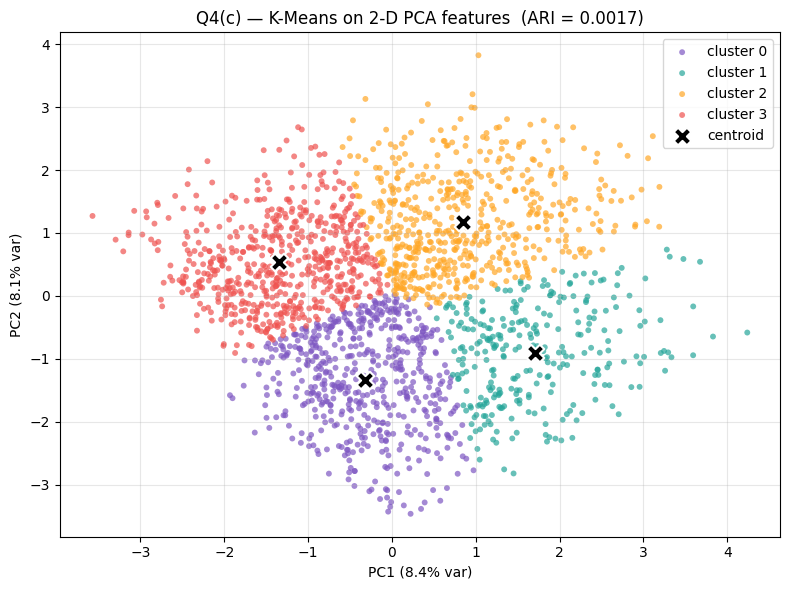

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for k in range(4):
    mask = labels_pca == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=18, alpha=0.7,
               color=cluster_colors[k], label=f'cluster {k}', edgecolor='none')

# Show centroids
ax.scatter(km_pca.cluster_centers_[:, 0], km_pca.cluster_centers_[:, 1],
           marker='X', s=160, c='black', edgecolor='white', linewidth=1.5,
           label='centroid', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(f'Q4(c) — K-Means on 2-D PCA features  (ARI = {ari_pca:.4f})')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('chart/Q4c_kmeans_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Q4(d) — Observations on (b) and (c)

### Headline numbers

| Setting | ARI |
|---|---:|
| Q4(b) — KMeans on all 20 standardised features | **0.0060** |
| Q4(c) — KMeans on 2-D PCA projection | **0.0017** |

PCA explains only **16.5%** of total variance with the first two components (PC1 = 8.4%, PC2 = 8.1%) — i.e. the variance is spread very evenly across the 20 dimensions and there is no dominant low-rank structure to exploit.

### Observations

1. **Both ARIs are essentially zero.** A perfect clustering would score 1.0; random clustering scores ~0. Both methods are sitting at the noise floor — K-Means is finding spatial groups, but those groups have **no relationship** to the true `price_range` labels. The crosstabs (next cell) confirm it: each cluster is roughly 25% of every class.

2. **(b) is marginally better than (c), but both are useless.** Going from 20-D to 2-D throws away ~83% of the variance, so it's not surprising that (c) does worse. The interesting fact is how *similar* they are — even keeping the full 20-D representation barely helps, which means the failure isn't a dimensionality problem.

3. **Why K-Means fails on this data.** The `price_range` label is dominated by **`ram`** (Q3 confirmed 68% of mid-cheap phones cluster on medium RAM, and Kaggle commentary on this dataset notes RAM has the highest correlation with price). After z-score standardisation, `ram` is *just one of 20 equally-weighted features*. The Euclidean distance K-Means uses gives equal weight to `dual_sim`, `wifi`, `touch_screen`, screen height, etc. — most of which carry little price signal. The genuine RAM signal gets drowned in noise from the other 19 features.

4. **Why PCA doesn't rescue it.** PCA finds the directions of *maximum variance*, which is **not the same** as directions of maximum class-discriminative power. PC1 captures whatever-the-most-variable-combination-of-features happens to be, even if that combination is uncorrelated with price. The plot in Q4(a) shows the four price classes overlapping almost completely in PC1–PC2 space, confirming PCA's directions don't align with the price gradient.

5. **The PCA scatter in 4(a) makes it visually obvious** — the four colours are mixed evenly, with no visible bands, gradients, or arcs separating them. There is no 2-D linear structure that K-Means could exploit even in principle.

### Implication for Q5

This failure is **a strong motivation for the ARM enhancement in Q5**: K-Means treats all features equally, but Q3 shows that information about price is highly concentrated in a small number of features. Association rule mining can identify the high-lift features and either re-weight the distance metric, seed initial centroids near class-distinctive rule patterns, or replace the raw feature space with a rule-based encoding — all of which break the "every feature is equally important" assumption that's tanking the baseline.

In [8]:
# Helper: cluster-vs-label crosstabs (since cluster ids are arbitrary, this shows where
# each cluster's members actually land in true class space).
print('=== Q4(b): KMeans-on-all-features cluster vs price_range ===')
print(pd.crosstab(labels_all, y, rownames=['cluster'], colnames=['price_range']))
print()
print('=== Q4(c): KMeans-on-PCA-2D cluster vs price_range ===')
print(pd.crosstab(labels_pca, y, rownames=['cluster'], colnames=['price_range']))

=== Q4(b): KMeans-on-all-features cluster vs price_range ===
price_range    0    1    2    3
cluster                        
0             81  116   98  149
1            127  119  113  111
2             97  109  131  113
3            195  156  158  127

=== Q4(c): KMeans-on-PCA-2D cluster vs price_range ===
price_range    0    1    2    3
cluster                        
0            142  148  141  115
1             83   70   72   66
2            133  132  159  145
3            142  150  128  174
